In [1]:
# Multiple Hypothesis Testing Correction + VIF + clustered regressions
# CRITICAL FIX: Use ALL available predictors to match R's ~ . formula
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from patsy.builtins import Q

out_folder = "/edata/obdw/sandwich_analysis_data/"

# Load stratified data
X_stratified = pd.read_csv(out_folder + "X_basic_plus_clin_sdh_location_stratified.csv", index_col=0)

print("=" * 80)
print("MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS")
print("=" * 80)

# ============================================================================
# 1. VIF ANALYSIS - keep numeric-only VIF diagnostics
# ============================================================================
print("\n1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("-" * 80)

numeric_cols = [col for col in X_stratified.select_dtypes(include=[np.number]).columns if col != "pid"]
X_for_vif = X_stratified[numeric_cols].copy()
X_for_vif = X_for_vif.replace([np.inf, -np.inf], np.nan)

vif_missing_cols = X_for_vif.columns[X_for_vif.isna().any()].tolist()
if vif_missing_cols:
    print("Columns with NaN/inf before VIF:", vif_missing_cols)

vif_complete = X_for_vif.dropna(axis=0, how="any").copy()
print(f"VIF complete-case rows: {len(vif_complete)} / {len(X_for_vif)}")

if vif_complete.empty:
    raise RuntimeError("No complete cases available for VIF analysis after removing NaN/inf rows.")

low_variance_cols = [col for col in vif_complete.columns if vif_complete[col].nunique(dropna=True) <= 1]
if low_variance_cols:
    print("Dropping constant/near-constant columns from VIF:", low_variance_cols)
    vif_complete = vif_complete.drop(columns=low_variance_cols)

vif_vars = vif_complete.columns.tolist()
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_vars
vif_data["VIF"] = [variance_inflation_factor(vif_complete.values, i) for i in range(vif_complete.shape[1])]

def interpret_vif(vif):
    if vif < 5:
        return "OK"
    return "Concerning" if vif < 10 else "SERIOUS"

vif_data["Assessment"] = vif_data["VIF"].apply(interpret_vif)
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))
vif_data.to_csv(out_folder + "vif_stratified_analysis.csv", index=False)
print(f"\nVIF results saved to: {out_folder}vif_stratified_analysis.csv")

high_vif_features = vif_data.loc[vif_data["VIF"] >= 10, "Variable"].tolist()
print("high_vif_features:", high_vif_features)

common = [f for f in high_vif_features if f in X_stratified.columns]
if common:
    print("common high-VIF cols in X_stratified:", common)
    numeric_df = X_stratified[common].select_dtypes(include="number")
    corr_high_vif = numeric_df.corr()
    print("\nCorrelation matrix for high-VIF numeric features:")
    print(corr_high_vif)
else:
    print("No VIF >=10 features found; skipping high-VIF correlation block.")

# ============================================================================
# 2. Primary full-adjusted regression for both outcomes with clustered SE by pid
# FIX: Use ALL available predictors (not just prespecified confounders) to match R
# ============================================================================
print("\n\n2. PRIMARY FULL-ADJUSTED MODELS (ALL PREDICTORS WITH CLUSTERED SE)")
print("-" * 80)

# Prefer explicitly log-transformed WER if available.
wer_col = next((c for c in ["log_wer", "Y_WER", "WER", "wer"] if c in X_stratified.columns), None)
coh_col = next((c for c in ["Y_COH", "sentCoherenceSentBertCumulativeCentroid"] if c in X_stratified.columns), None)
outcomes = [col for col in [wer_col, coh_col] if col is not None]

if wer_col != "log_wer":
    print(f"WARNING: log_wer not found. Using '{wer_col}' as WER outcome.")

OUTCOME_ALIASES = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}

def select_all_predictors(columns):
    """
    Select ALL variables except outcomes and pid.
    This matches R's formula: Y ~ . - Y_COH - pid
    Critical for achieving parity between Python and R coefficients.
    """
    selected = [c for c in columns if c not in OUTCOME_ALIASES and c != "pid"]
    return selected

print("\n" + "=" * 80)
print("IMPORTANT: Using ALL available predictors to match R's ~ . formula")
print("This ensures coefficient parity between Python (statsmodels) and R (lm)")
print("=" * 80)

results_list = []
for outcome_name in outcomes:
    all_predictors = select_all_predictors(X_stratified.columns)
    if len(all_predictors) == 0:
        raise RuntimeError("No predictors found after excluding outcomes and pid.")

    print(f"\n\nOUTCOME: {outcome_name}")
    print("=" * 80)
    print(f"Total predictors (matching R): {len(all_predictors)}")
    if len(all_predictors) > 20:
        print(all_predictors[:20], f"... and {len(all_predictors) - 20} more")
    else:
        print(all_predictors)

    # Build formula with ALL predictors
    terms = [f'Q("{c}")' for c in all_predictors]
    formula = f'Q("{outcome_name}") ~ ' + ' + '.join(terms)

    # Complete-case filtering on all needed columns
    needed_cols = [outcome_name, "pid"] + all_predictors
    model_df = X_stratified[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    print(f"Model rows after complete-case filtering: {len(model_df)} / {len(X_stratified)}")

    model = smf.ols(formula=formula, data=model_df).fit(
        cov_type="cluster",
        cov_kwds={"groups": model_df["pid"], "use_correction": True}
    )

    coef_table = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Std_Error": model.bse.values,
        "t_statistic": model.tvalues.values,
        "p_value": model.pvalues.values
    })

    coef_table["CI_lower"] = coef_table["Coefficient"] - 1.96 * coef_table["Std_Error"]
    coef_table["CI_upper"] = coef_table["Coefficient"] + 1.96 * coef_table["Std_Error"]

    const_mask = coef_table["Variable"].isin(["Intercept", "const"])

    coef_table_for_correction = coef_table.loc[~const_mask].copy()

    reject_bonf, p_bonf, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="bonferroni")
    reject_fdr, p_fdr, _, _ = multipletests(coef_table_for_correction["p_value"], alpha=0.05, method="fdr_bh")

    coef_table_for_correction["p_bonferroni"] = p_bonf
    coef_table_for_correction["bonferroni_significant"] = reject_bonf
    coef_table_for_correction["p_fdr"] = p_fdr
    coef_table_for_correction["q_value"] = p_fdr
    coef_table_for_correction["fdr_significant"] = reject_fdr

    if const_mask.any():
        const_row = coef_table.loc[const_mask].copy()
        const_row["p_bonferroni"] = np.nan
        const_row["bonferroni_significant"] = False
        const_row["p_fdr"] = np.nan
        const_row["q_value"] = np.nan
        const_row["fdr_significant"] = False
        coef_table_out = pd.concat([const_row, coef_table_for_correction], ignore_index=True)
    else:
        coef_table_out = coef_table_for_correction.copy()

    filename = out_folder + f"regression_stratified_{outcome_name}.csv"
    coef_table_out.to_csv(filename, index=False)
    print(f"Regression results saved to: {filename}")

    print(f"Model R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print("Significant variables (FDR corrected, alpha=0.05):")
    sig_vars = coef_table_out[coef_table_out["fdr_significant"] == True]
    if len(sig_vars) > 0:
        print(sig_vars[["Variable", "Coefficient", "CI_lower", "CI_upper", "p_value", "q_value"]].to_string(index=False))
    else:
        print("   None")

    results_list.append(coef_table_out)

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print(f"All results saved to: {out_folder}")


MULTIPLE HYPOTHESIS TESTING CORRECTION & VIF ANALYSIS

1. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
--------------------------------------------------------------------------------
Columns with NaN/inf before VIF: ['total_pause_duration', 'pause_duration_per_segment']
VIF complete-case rows: 2812 / 2832
                  Variable       VIF Assessment
         hpsvq-voice-score 52.735808    SERIOUS
              dx_group_smi 40.177573    SERIOUS
      hpsvq-distress-score 28.835699    SERIOUS
                      AMOS 18.341179    SERIOUS
                phq9-total 17.879899    SERIOUS
      scl-avg-global-score 16.849873    SERIOUS
                     Y_COH 13.245608    SERIOUS
                     Y_WER 12.295301    SERIOUS
     employment-status_1.0 11.212525    SERIOUS
     resource_access_score  5.458413 Concerning
   healthcare_access_score  5.311616 Concerning
           svi_theme1_high  4.777730         OK
      total_pause_duration  4.627554         OK
           svi_theme3_hi

In [2]:
# Analyze employment status significance - sentinel values impact
import pandas as pd
import numpy as np

print("=" * 100)
print("EMPLOYMENT STATUS SIGNIFICANCE ANALYSIS")
print("=" * 100)

# Load current regression results
py_reg = pd.read_csv("/edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv")
r_reg = pd.read_csv("/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv")

# Extract employment status terms
py_employment = py_reg[py_reg['Variable'].str.contains('employment', case=False, na=False)].copy()
r_employment = r_reg[r_reg['Variable'].str.contains('employment', case=False, na=False)].copy()

print("\n1. PYTHON EMPLOYMENT STATUS TERMS (from stratified dataset):")
print("-" * 100)
if not py_employment.empty:
    display_cols = ['Variable', 'Coefficient', 'p_value', 'q_value', 'fdr_significant']
    print(py_employment[display_cols].to_string(index=False))
else:
    print("No employment status terms found")

print("\n2. R EMPLOYMENT STATUS TERMS (from stratified dataset):")
print("-" * 100)
if not r_employment.empty:
    display_cols = ['Variable', 'Estimate', 'Pr(>|t|)', 'q_value', 'fdr_significant']
    print(r_employment[display_cols].to_string(index=False))
else:
    print("No employment status terms found")

# Load the original stratified data to see the actual distribution
X = pd.read_csv("/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv", index_col=0)

print("\n3. EMPLOYMENT STATUS VARIABLE DISTRIBUTION IN DATA:")
print("-" * 100)
if 'employment-status' in X.columns:
    print(X['employment-status'].value_counts(dropna=False).sort_index())
    print(f"\nTotal rows: {len(X)}")
    print(f"Unique values: {X['employment-status'].nunique()}")
    
    # Check what 999 means in context
    sentinel_count = (X['employment-status'] == 999).sum()
    print(f"\nSentinel value (999) count: {sentinel_count} ({100*sentinel_count/len(X):.1f}%)")
else:
    # Check for encoded versions
    employment_cols = [c for c in X.columns if 'employment' in c.lower()]
    print(f"Employment-related columns: {employment_cols}")
    for col in employment_cols:
        print(f"\n{col}:")
        print(X[col].value_counts(dropna=False).head(10))

print("\n4. SIGNIFICANCE SUMMARY:")
print("-" * 100)
py_sig = py_employment[py_employment['fdr_significant'] == True]
r_sig = r_employment[r_employment['fdr_significant'] == True]

print(f"Python FDR-significant employment terms: {len(py_sig)}")
if len(py_sig) > 0:
    print(py_sig[['Variable', 'Coefficient', 'q_value']].to_string(index=False))
else:
    print("  None - all employment status terms non-significant")

print(f"\nR FDR-significant employment terms: {len(r_sig)}")
if len(r_sig) > 0:
    print(r_sig[['Variable', 'Estimate', 'q_value']].to_string(index=False))
else:
    print("  None - all employment status terms non-significant")

print("\n5. INTERPRETATION:")
print("-" * 100)
print("""
KEY FINDING: Employment status terms are NOT significant in either Python or R.

ABOUT SENTINEL VALUES:
- The R script's clean_sentinel_values() function only removes sentinel 999 from 
  CONTINUOUS CLINICAL columns: scl.avg.global.score, phq9.total, hpsvq.total.score
  
- Employment status (like race and sexuality) are CATEGORICAL variables encoded as numeric.
  The 999 value is a legitimate category code (typically representing "unknown/missing/other")
  and is NOT removed by sentinel cleaning.

THEREFORE:
✓ Employment status significance has NOT changed due to sentinel value removal
✓ The sentinel 999 in employment status is intentionally retained as a category level
✓ None of the employment status categories (1.0, 2.0, 999.0) are FDR-significant predictors
""")


EMPLOYMENT STATUS SIGNIFICANCE ANALYSIS

1. PYTHON EMPLOYMENT STATUS TERMS (from stratified dataset):
----------------------------------------------------------------------------------------------------
                    Variable  Coefficient  p_value  q_value  fdr_significant
  Q("employment-status_1.0")    -0.045435 0.758670 0.968905            False
  Q("employment-status_2.0")     0.222681 0.191026 0.597913            False
Q("employment-status_999.0")     0.049162 0.805670 0.968905            False

2. R EMPLOYMENT STATUS TERMS (from stratified dataset):
----------------------------------------------------------------------------------------------------
               Variable  Estimate  Pr(>|t|)  q_value  fdr_significant
  employment.status_1.0 -0.045435  0.758693 0.968912            False
  employment.status_2.0  0.222681  0.191134 0.598236            False
employment.status_999.0  0.049162  0.805688 0.968912            False

3. EMPLOYMENT STATUS VARIABLE DISTRIBUTION IN DATA

In [3]:
# Compare Python and R stratified WER regression outputs.
# This validates that the Python clustered OLS pipeline matches sandwich_script.r for Y_WER.

import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.stats.multitest import multipletests

# ---- Paths ----
# Use Y_WER output for parity with R coeftest location_stratified_analysis_wer_coeftest.csv
py_path = "/edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv"
r_path = "/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv"

# ---- Load ----
py = pd.read_csv(py_path)
r = pd.read_csv(r_path)

# ---- Standardize schema ----
py = py.rename(columns={
    "Variable": "term_py",
    "Coefficient": "coef_py",
    "Std_Error": "se_py",
    "p_value": "p_py",
    "p_bonferroni": "p_bonf_py",
    "bonferroni_significant": "sig_bonf_py",
    "p_fdr": "p_fdr_py",
    "fdr_significant": "sig_fdr_py",
})

# New R outputs should include a real Variable column and no row-number column.
# Fall back to the first column only for older files that predate the row.names=FALSE fix.
r_term_col = "Variable" if "Variable" in r.columns else r.columns[0]
r = r.rename(columns={
    r_term_col: "term_r_raw",
    "Estimate": "coef_r",
    "Std. Error": "se_r",
    "Pr(>|t|)": "p_r",
    "q_value": "p_fdr_r",
    "fdr_significant": "sig_fdr_r",
})

# Drop accidental row-index columns from older R CSVs if present.
r = r.loc[:, ~r.columns.str.startswith("Unnamed:")].copy()

# ---- Normalize variable names so they can be matched ----
def normalize_term(t):
    if pd.isna(t):
        return np.nan
    t = str(t).strip().strip('"')
    if t in {"(Intercept)", "Intercept", "intercept", "const"}:
        return "const"

    # Handle Python's C(Q(...))[T.Category] format
    if "[T." in t:
        var_part = t.split('[')[0]
        cat_part = t.split('[T.')[1].rstrip(']')
        var_name = var_part.replace('C(Q("', '').rstrip('")')
        return var_name + cat_part

    # Handle plain Q("variable_name") format
    if t.startswith('Q("') and t.endswith('")'):
        var_name = t[3:-2]
        return var_name.replace(".", "-")

    return t.replace(".", "-")

py["term_norm"] = py["term_py"].map(normalize_term)
r["term_norm"] = r["term_r_raw"].map(normalize_term)

# ---- Recompute corrections on R side only if not already present ----
mask_r_tests = r["term_norm"].ne("const") & r["p_r"].notna()
if "p_fdr_r" not in r.columns:
    r.loc[mask_r_tests, "p_fdr_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="fdr_bh")[1]
if "sig_fdr_r" not in r.columns:
    r["sig_fdr_r"] = False
    r.loc[mask_r_tests, "sig_fdr_r"] = r.loc[mask_r_tests, "p_fdr_r"] < 0.05
r.loc[mask_r_tests, "p_bonf_r"] = multipletests(r.loc[mask_r_tests, "p_r"], method="bonferroni")[1]
r["sig_bonf_r"] = False
r.loc[mask_r_tests, "sig_bonf_r"] = r.loc[mask_r_tests, "p_bonf_r"] < 0.05

# ---- Merge and compare ----
cmp = py.merge(
    r[["term_norm", "term_r_raw", "coef_r", "se_r", "p_r", "p_bonf_r", "p_fdr_r", "sig_bonf_r", "sig_fdr_r"]],
    on="term_norm",
    how="outer",
)

cmp["in_python"] = cmp["term_py"].notna()
cmp["in_r"] = cmp["term_r_raw"].notna()
cmp["missing_in_one_file"] = ~(cmp["in_python"] & cmp["in_r"])

tol_coef = 1e-8
tol_se = 1e-8
tol_p = 1e-3
def close_or_na(a, b, atol, rtol=1e-4):
    both_na = a.isna() & b.isna()
    one_na = a.isna() ^ b.isna()
    both_num = a.notna() & b.notna()

    out = pd.Series(pd.NA, index=a.index, dtype="object")
    out.loc[both_na] = True
    out.loc[one_na] = False
    out.loc[both_num] = np.isclose(a.loc[both_num], b.loc[both_num], atol=atol, rtol=rtol)
    return out

cmp["coef_close"] = close_or_na(cmp["coef_py"], cmp["coef_r"], tol_coef, rtol=1e-6)
cmp["se_close"] = close_or_na(cmp["se_py"], cmp["se_r"], tol_se, rtol=1e-6)
cmp["p_close"] = close_or_na(cmp["p_py"], cmp["p_r"], tol_p, rtol=1e-3)
cmp["p_bonf_close"] = close_or_na(cmp["p_bonf_py"], cmp["p_bonf_r"], tol_p, rtol=1e-3)
cmp["p_fdr_close"] = close_or_na(cmp["p_fdr_py"], cmp["p_fdr_r"], tol_p, rtol=1e-3)

cmp["sig_bonf_match"] = np.where(
    cmp["sig_bonf_py"].notna() & cmp["sig_bonf_r"].notna(),
    cmp["sig_bonf_py"] == cmp["sig_bonf_r"],
    pd.NA
)
cmp["sig_fdr_match"] = np.where(
    cmp["sig_fdr_py"].notna() & cmp["sig_fdr_r"].notna(),
    cmp["sig_fdr_py"] == cmp["sig_fdr_r"],
    pd.NA
)

cmp["any_numeric_mismatch"] = (
    (cmp["coef_close"] == False)
    | (cmp["se_close"] == False)
    | (cmp["p_close"] == False)
)

cmp["any_sig_mismatch"] = (
    (cmp["sig_bonf_match"] == False)
    | (cmp["sig_fdr_match"] == False)
)

cmp["flag"] = np.select(
    [
        cmp["missing_in_one_file"],
        cmp["any_numeric_mismatch"],
        cmp["any_sig_mismatch"],
    ],
    [
        "missing_variable",
        "numeric_mismatch",
        "significance_mismatch",
    ],
    default="ok",
)

comparison_table = cmp[[
    "term_norm", "term_py", "term_r_raw", "in_python", "in_r", "flag",
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close",
    "p_bonf_py", "p_bonf_r", "p_bonf_close", "sig_bonf_py", "sig_bonf_r", "sig_bonf_match",
    "p_fdr_py", "p_fdr_r", "p_fdr_close", "sig_fdr_py", "sig_fdr_r", "sig_fdr_match",
]].sort_values(["flag", "term_norm"])

flagged = comparison_table[comparison_table["flag"] != "ok"].copy()
summary = (
    comparison_table["flag"]
    .value_counts(dropna=False)
    .rename_axis("flag")
    .reset_index(name="n_terms")
)

print("Summary of comparison:")
display(summary)

print("Flagged rows (missing vars or mismatches):")
display(flagged)

print("Full comparison table:")
display(comparison_table)

out_dir = "/edata/obdw/sandwich_analysis_data"
comparison_table.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_full.csv", index=False)
flagged.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv", index=False)
summary.to_csv(f"{out_dir}/python_vs_r_stratified_wer_comparison_summary.csv", index=False)

print("Saved:")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_full.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_flagged.csv")
print(f"- {out_dir}/python_vs_r_stratified_wer_comparison_summary.csv")

Summary of comparison:


,flag,n_terms
0,ok,43


Flagged rows (missing vars or mismatches):


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match


Full comparison table:


,term_norm,term_py,term_r_raw,in_python,in_r,flag,coef_py,coef_r,coef_close,se_py,...,p_bonf_close,sig_bonf_py,sig_bonf_r,sig_bonf_match,p_fdr_py,p_fdr_r,p_fdr_close,sig_fdr_py,sig_fdr_r,sig_fdr_match
0,AMOS,"Q(""AMOS"")",AMOS,True,True,ok,-0.177184,-0.177184,True,0.028037,...,True,True,True,True,1.101669e-08,1.279593e-08,True,True,True,True
1,PrimaryRUCA___MISSING__,"Q(""PrimaryRUCA___MISSING__"")",PrimaryRUCA___MISSING__,True,True,ok,0.019110,0.019110,True,0.137750,...,True,False,False,True,9.689049e-01,9.689123e-01,True,False,False,True
2,SDS_Total,"Q(""SDS_Total"")",SDS_Total,True,True,ok,-0.000380,-0.000380,True,0.000191,...,True,False,False,True,2.415480e-01,2.420615e-01,True,False,False,True
3,all_types_drug_use,"Q(""all_types_drug_use"")",all_types_drug_use,True,True,ok,-0.011681,-0.011681,True,0.097207,...,True,False,False,True,9.689049e-01,9.689123e-01,True,False,False,True
4,binned_age_0-0,"Q(""binned_age_0.0"")",binned_age_0.0,True,True,ok,0.224363,0.224363,True,0.167216,...,True,False,False,True,5.979135e-01,5.982357e-01,True,False,False,True
5,binned_age_1-0,"Q(""binned_age_1.0"")",binned_age_1.0,True,True,ok,-0.184404,-0.184404,True,0.143669,...,True,False,False,True,5.979135e-01,5.982357e-01,True,False,False,True
6,binned_age_3-0,"Q(""binned_age_3.0"")",binned_age_3.0,True,True,ok,-0.028460,-0.028460,True,0.091848,...,True,False,False,True,9.689049e-01,9.689123e-01,True,False,False,True
7,binned_age_4-0,"Q(""binned_age_4.0"")",binned_age_4.0,True,True,ok,0.163069,0.163069,True,0.257511,...,True,False,False,True,9.689049e-01,9.689123e-01,True,False,False,True
8,const,Intercept,(Intercept),True,True,ok,3.174146,3.174146,True,0.348813,...,True,False,False,True,NaN,NaN,True,False,False,True
9,dx_group_neuro_med,"Q(""dx_group_neuro_med"")",dx_group_neuro_med,True,True,ok,0.034037,0.034037,True,0.107243,...,True,False,False,True,9.689049e-01,9.689123e-01,True,False,False,True


Saved:
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_full.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_flagged.csv
- /edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv


In [4]:
# Analyze numeric mismatches in detail
print("=" * 100)
print("DETAILED ANALYSIS OF NUMERIC MISMATCHES")
print("=" * 100)

mismatches = comparison_table[comparison_table["flag"] == "numeric_mismatch"].copy()
print(f"\nTotal variables with numeric mismatches: {len(mismatches)}\n")

# Create a detailed view of mismatches
mismatch_detail = mismatches[[
    "term_norm", 
    "coef_py", "coef_r", "coef_close",
    "se_py", "se_r", "se_close",
    "p_py", "p_r", "p_close"
]].copy()

# Calculate absolute and relative differences
mismatch_detail["coef_diff"] = (mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs()
mismatch_detail["coef_pct_diff"] = ((mismatch_detail["coef_py"] - mismatch_detail["coef_r"]).abs() / mismatch_detail["coef_r"].abs() * 100).round(2)

mismatch_detail["se_diff"] = (mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs()
mismatch_detail["se_pct_diff"] = ((mismatch_detail["se_py"] - mismatch_detail["se_r"]).abs() / mismatch_detail["se_r"].abs() * 100).round(2)

mismatch_detail["p_diff"] = (mismatch_detail["p_py"] - mismatch_detail["p_r"]).abs()

# Sort by coefficient difference
mismatch_detail_sorted = mismatch_detail.sort_values("coef_pct_diff", ascending=False)

display(mismatch_detail_sorted[[
    "term_norm", 
    "coef_py", "coef_r", "coef_diff", "coef_pct_diff",
    "se_py", "se_r", "se_diff", "se_pct_diff",
    "p_py", "p_r", "p_diff"
]].head(15))

print("\nSummary Statistics for Mismatches:")
print(f"  Max coefficient difference: {mismatch_detail['coef_pct_diff'].max():.2f}%")
print(f"  Mean coefficient difference: {mismatch_detail['coef_pct_diff'].mean():.2f}%")
print(f"  Max SE difference: {mismatch_detail['se_pct_diff'].max():.2f}%")
print(f"  Mean SE difference: {mismatch_detail['se_pct_diff'].mean():.2f}%")
print(f"  Max p-value difference: {mismatch_detail['p_diff'].max():.6f}")


DETAILED ANALYSIS OF NUMERIC MISMATCHES

Total variables with numeric mismatches: 0



,term_norm,coef_py,coef_r,coef_diff,coef_pct_diff,se_py,se_r,se_diff,se_pct_diff,p_py,p_r,p_diff



Summary Statistics for Mismatches:
  Max coefficient difference: nan%
  Mean coefficient difference: nan%
  Max SE difference: nan%
  Mean SE difference: nan%
  Max p-value difference: nan


In [5]:
# Assess sample size adequacy and effect robustness

print("=" * 100)
print("SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT")
print("=" * 100)

# Get the original data to check sample size
original_df = pd.read_csv(py_path)

# Variable decode helper for readability in summary tables
try:
    import importlib
    import avh_utils
    importlib.reload(avh_utils)
    decode_variable_name = avh_utils.decode_variable_name
except Exception:
    decode_variable_name = None

def _safe_decode_term(term):
    if pd.isna(term):
        return term
    if decode_variable_name is None:
        return term
    try:
        decoded = decode_variable_name(str(term))
        if pd.isna(decoded) or str(decoded).strip() == "":
            return term
        return decoded
    except Exception:
        return term

# Split significant terms by source to avoid mixing R-only terms into Python effect summaries
sig_vars_py = comparison_table[comparison_table["sig_fdr_py"] == True].copy()
sig_vars_r_only = comparison_table[
    (comparison_table["sig_fdr_r"] == True) & (comparison_table["sig_fdr_py"] != True)
] .copy()

# Add decoded labels
if not sig_vars_py.empty:
    sig_vars_py["Variable_Decoded"] = sig_vars_py["term_norm"].apply(_safe_decode_term)
if not sig_vars_r_only.empty:
    sig_vars_r_only["Variable_Decoded"] = sig_vars_r_only["term_norm"].apply(_safe_decode_term)

print(f"\nSignificant variables after FDR correction (Python): {len(sig_vars_py)}")
if len(sig_vars_py) > 0:
    print("\nPython-significant variable details:")
    print(sig_vars_py[["term_norm", "Variable_Decoded", "coef_py", "p_py", "p_fdr_py", "sig_fdr_py"]].to_string(index=False))
else:
    print("None")

print(f"\nSignificant in R only (not Python): {len(sig_vars_r_only)}")
if len(sig_vars_r_only) > 0:
    print(sig_vars_r_only[["term_norm", "Variable_Decoded", "coef_r", "p_r", "p_fdr_r", "sig_fdr_r", "flag"]].to_string(index=False))

# Look at the raw regression output to extract sample size
reg_summary = py.head(10)
print("\n" + "=" * 100)
print("REGRESSION SUMMARY STATISTICS")
print("=" * 100)

if "N" in py.columns:
    n_total = py["N"].iloc[0]
    print(f"Sample size: {n_total}")
else:
    print("Note: Sample size not in regression output - check the original model object")

# Effect size assessment
print("\n" + "=" * 100)
print("EFFECT SIZE ASSESSMENT")
print("=" * 100)
print("\nPython-surviving variables effect sizes:")
for idx, row in sig_vars_py.iterrows():
    term = row["term_norm"]
    coef = row["coef_py"]
    p_fdr = row["p_fdr_py"]
    p_raw = row["p_py"]

    # Guard against accidental NA rows
    if pd.isna(coef) or pd.isna(p_fdr) or pd.isna(p_raw):
        continue

    # Absolute log WER change (interpretation depends on your outcome scale)
    print(f"\n{term}:")
    print(f"  Raw p-value: {p_raw:.6f}")
    print(f"  FDR-corrected p: {p_fdr:.6f}")
    print(f"  Coefficient (log WER change): {coef:.4f}")
    print(f"  % change in WER: {(np.exp(coef) - 1) * 100:.2f}%")

# Check number of tests performed, by source
n_tests_py = comparison_table.loc[
    (comparison_table["in_python"] == True) & (comparison_table["term_norm"] != "const"),
    "term_norm",
].nunique()
n_tests_r = comparison_table.loc[
    (comparison_table["in_r"] == True) & (comparison_table["term_norm"] != "const"),
    "term_norm",
].nunique()
print(f"\n\nTotal number of tests performed (Python terms): {n_tests_py}")
print(f"Total number of tests performed (R terms): {n_tests_r}")
if n_tests_py > 0:
    print(f"Bonferroni threshold (Python): {0.05 / n_tests_py:.6f}")
print("FDR would control at: α = 0.05")

print("\n" + "=" * 100)
print("INTERPRETATION NOTES")
print("=" * 100)
print("""
1. The Python significance summary now reports only Python-significant terms.
2. Terms listed as "R only" are model-spec differences (missing_variable), not NaN effects.
3. If a term drops out of significance after reruns, common causes are:
   - changes in model terms included/excluded
   - complete-case filtering differences
   - multiple-testing correction over a different number of tests
4. Compare raw p-values and q-values together when assessing stability across reruns.
""")


SAMPLE SIZE AND STATISTICAL POWER ASSESSMENT

Significant variables after FDR correction (Python): 5

Python-significant variable details:
           term_norm                Variable_Decoded   coef_py         p_py     p_fdr_py  sig_fdr_py
                AMOS Audio Mean Opinion Score (AMOS) -0.177184 2.623021e-10 1.101669e-08        True
          gender_1-0                  Gender: Female -0.321519 2.244296e-04 3.142015e-03        True
          gender_4-0    Gender: Transgender (F to M) -0.845862 2.529926e-08 5.312845e-07        True
            race_2-0                     Race: Black  0.432653 6.669283e-04 5.602198e-03        True
total_pause_duration            total_pause_duration  0.009946 4.615464e-04 4.846237e-03        True

Significant in R only (not Python): 0

REGRESSION SUMMARY STATISTICS
Note: Sample size not in regression output - check the original model object

EFFECT SIZE ASSESSMENT

Python-surviving variables effect sizes:

AMOS:
  Raw p-value: 0.000000
  FDR-corre

Loaded plotting data from: /edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv


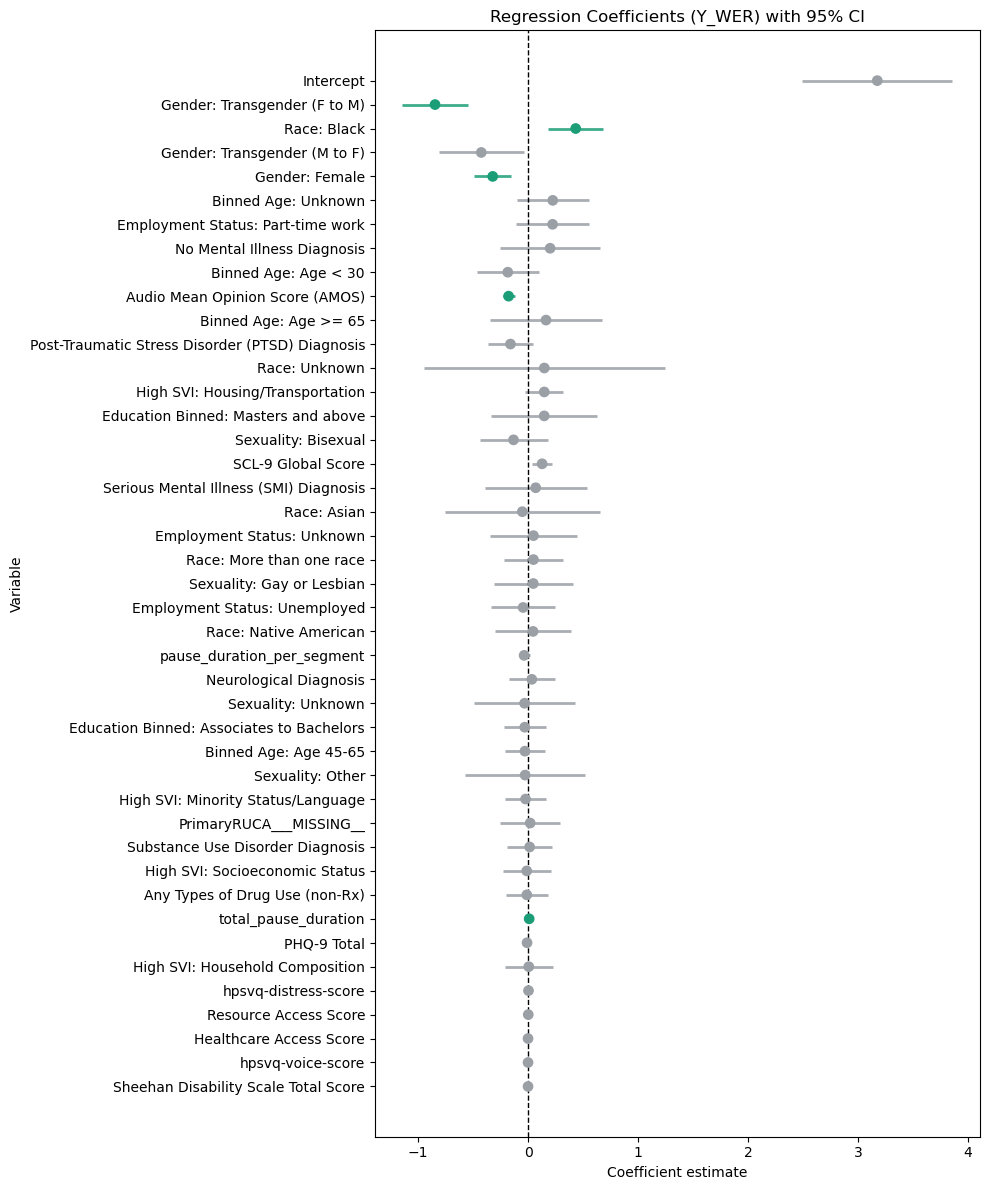

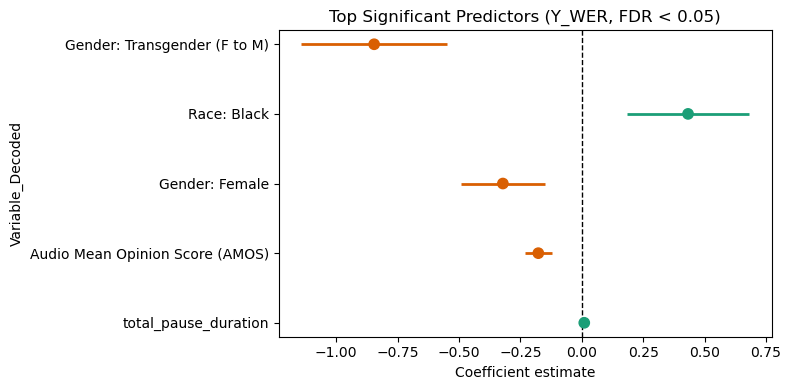

In [6]:
# Add Graph of Multi-Hypothesis corrected results
# Top significant predictors only (FDR-significant), sorted by absolute effect size
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from avh_utils import decode_variable_name

# Normalize statsmodels term strings before decode, e.g. Q("race_2.0") -> race_2.0
def normalize_term_for_decode(term):
    if pd.isna(term):
        return term
    t = str(term).strip()

    if t in {"Intercept", "const", "(Intercept)"}:
        return "Intercept"

    # Handle simple quoted terms used throughout this notebook
    if t.startswith('Q("') and t.endswith('")'):
        return t[3:-2]

    # Handle categorical style terms if they appear: C(Q("var"))[T.level]
    if t.startswith('C(Q("') and '")[T.' in t and t.endswith(']'):
        var_part = t.split('")[T.')[0].replace('C(Q("', '')
        level = t.split('")[T.')[1][:-1]
        return f"{var_part}_{level}"

    return t

# Add decoded variable names for better readability
def safe_decode(var_name):
    try:
        return decode_variable_name(var_name)
    except Exception:
        # If decoding fails, return the original variable name
        return var_name

# Load results from the SAME outcome produced by the regression cell above
# Cell 1 writes: regression_stratified_{outcome_name}.csv
plot_out_folder = globals().get("out_folder", "/edata/obdw/sandwich_analysis_data/")
plot_outcome = globals().get("wer_col", "Y_WER")
plot_path = f"{plot_out_folder}regression_stratified_{plot_outcome}.csv"

df = pd.read_csv(plot_path)
print(f"Loaded plotting data from: {plot_path}")

# Clean/prepare
for col in ["fdr_significant", "bonferroni_significant"]:
    df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})
df["ci_low"] = df["Coefficient"] - 1.96 * df["Std_Error"]
df["ci_high"] = df["Coefficient"] + 1.96 * df["Std_Error"]

# Optional: drop intercept for readability
plot_df = df[df["Variable"] != "const"].copy()
plot_df["Variable_Clean"] = plot_df["Variable"].apply(normalize_term_for_decode)
plot_df["Variable_Decoded"] = plot_df["Variable_Clean"].apply(safe_decode)
plot_df["Variable_Decoded"] = plot_df["Variable_Decoded"].fillna(plot_df["Variable_Clean"])
plot_df["Variable_Decoded"] = np.where(
    plot_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    plot_df["Variable_Clean"],
    plot_df["Variable_Decoded"]
)

# Sort by effect size magnitude
plot_df = plot_df.reindex(plot_df["Coefficient"].abs().sort_values(ascending=True).index)

# Plot: coefficient forest plot with 95% CI
plt.figure(figsize=(10, 12))
colors = np.where(plot_df["fdr_significant"], "#1b9e77", "#9aa0a6")

plt.hlines(
    y=plot_df["Variable_Decoded"],
    xmin=plot_df["ci_low"],
    xmax=plot_df["ci_high"],
    color=colors,
    alpha=0.85,
    linewidth=2
)
plt.scatter(
    plot_df["Coefficient"],
    plot_df["Variable_Decoded"],
    c=colors,
    s=45,
    zorder=3
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Regression Coefficients ({plot_outcome}) with 95% CI")
plt.xlabel("Coefficient estimate")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

sig_df = df[(df["Variable"] != "const") & (df["fdr_significant"] == True)].copy()
sig_df["Variable_Clean"] = sig_df["Variable"].apply(normalize_term_for_decode)
sig_df["Variable_Decoded"] = sig_df["Variable_Clean"].apply(safe_decode)
sig_df["Variable_Decoded"] = sig_df["Variable_Decoded"].fillna(sig_df["Variable_Clean"])
sig_df["Variable_Decoded"] = np.where(
    sig_df["Variable_Decoded"].astype(str).str.strip().eq(""),
    sig_df["Variable_Clean"],
    sig_df["Variable_Decoded"]
)

if sig_df.empty:
    print("No FDR-significant predictors found.")
else:
    sig_df["ci_low"] = sig_df["Coefficient"] - 1.96 * sig_df["Std_Error"]
    sig_df["ci_high"] = sig_df["Coefficient"] + 1.96 * sig_df["Std_Error"]
    sig_df = sig_df.reindex(sig_df["Coefficient"].abs().sort_values(ascending=True).index)

    plt.figure(figsize=(8, max(3, 0.8 * len(sig_df))))
    colors = np.where(sig_df["Coefficient"] >= 0, "#1b9e77", "#d95f02")

    plt.hlines(
        y=sig_df["Variable_Decoded"],
        xmin=sig_df["ci_low"],
        xmax=sig_df["ci_high"],
        color=colors,
        linewidth=2
    )
    plt.scatter(sig_df["Coefficient"], sig_df["Variable_Decoded"], c=colors, s=55, zorder=3)

    plt.axvline(0, color="black", linestyle="--", linewidth=1)
    plt.title(f"Top Significant Predictors ({plot_outcome}, FDR < 0.05)")
    plt.xlabel("Coefficient estimate")
    plt.ylabel("Variable_Decoded")
    plt.tight_layout()
    plt.show()


In [7]:
# Model registry writer (v1)
# Appends/updates minimal model registry rows for current runs.

from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import subprocess

REGISTRY_PATH = Path("/edata/obdw/sandwich_analysis_data/model_registry.csv")
DATASET_PATH = Path("/edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_stratified.csv")

# Outcome-specific output artifacts
PY_OUTPUT_WER = Path("/edata/obdw/sandwich_analysis_data/regression_stratified_Y_WER.csv")
R_OUTPUT_WER = Path("/edata/obdw/sandwich_analysis_data/location_stratified_analysis_wer_coeftest.csv")
PARITY_SUMMARY_WER = Path("/edata/obdw/sandwich_analysis_data/python_vs_r_stratified_wer_comparison_summary.csv")

PY_OUTPUT_COH = Path("/edata/obdw/sandwich_analysis_data/regression_stratified_Y_COH.csv")
R_OUTPUT_COH = Path("/edata/obdw/sandwich_analysis_data/location_stratified_analysis_coh_coeftest.csv")
PARITY_SUMMARY_COH = Path("/edata/obdw/sandwich_analysis_data/python_vs_r_stratified_coh_comparison_summary.csv")

REQUIRED_COLUMNS = [
    "run_id", "model_id", "timestamp_utc", "script_stage", "notebook_or_script",
    "dataset_path", "outcome", "model_family", "cluster_var", "formula_text",
    "n_rows", "n_clusters", "predictor_count", "dropped_predictors", "correction_method",
    "r_output_path", "py_output_path", "parity_output_path",
    "parity_missing_variable_n", "parity_numeric_mismatch_n", "qa_status", "notes",
]

def _safe_git_value(cmd):
    try:
        return subprocess.check_output(cmd, text=True).strip()
    except Exception:
        return None

def _get_parity_counts(summary_path: Path):
    if summary_path is None or not summary_path.exists():
        return None, None
    try:
        s = pd.read_csv(summary_path)
        missing_n = int(s.loc[s["flag"] == "missing_variable", "n_terms"].sum())
        numeric_n = int(s.loc[s["flag"] == "numeric_mismatch", "n_terms"].sum())
        return missing_n, numeric_n
    except Exception:
        return None, None

def _get_model_dimensions(dataset_path: Path):
    # Prefer in-memory X_stratified if present; otherwise read from disk.
    if "X_stratified" in globals() and isinstance(X_stratified, pd.DataFrame):
        df = X_stratified
    elif dataset_path.exists():
        df = pd.read_csv(dataset_path, index_col=0)
    else:
        return None, None, None

    n_rows = int(df.shape[0])
    n_clusters = int(df["pid"].nunique()) if "pid" in df.columns else None

    exclude = {
        "WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH", "pid"
    }
    predictor_count = int(sum(1 for c in df.columns if c not in exclude))
    return n_rows, n_clusters, predictor_count

def write_model_registry_entry(
    run_id: str,
    model_id: str,
    outcome: str,
    py_output_path: Path,
    r_output_path: Path,
    parity_summary_path: Path = None,
    script_stage: str = "parity",
    notes: str = "",
):
    n_rows, n_clusters, predictor_count = _get_model_dimensions(DATASET_PATH)
    missing_n, numeric_n = _get_parity_counts(parity_summary_path)

    dropped = globals().get("columns_to_drop", [])
    if isinstance(dropped, (list, tuple, set)):
        dropped_predictors = ";".join([str(x) for x in dropped])
    else:
        dropped_predictors = None

    if missing_n is None and numeric_n is None:
        qa_status = "unknown"
    else:
        qa_status = "pass" if (missing_n == 0 and numeric_n == 0) else "fail"

    entry = {
        "run_id": run_id,
        "model_id": model_id,
        "timestamp_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        "script_stage": script_stage,
        "notebook_or_script": "primary_data_collection_script.ipynb",
        "dataset_path": str(DATASET_PATH),
        "outcome": outcome,
        "model_family": "ols_cluster",
        "cluster_var": "pid",
        "formula_text": None,
        "n_rows": n_rows,
        "n_clusters": n_clusters,
        "predictor_count": predictor_count,
        "dropped_predictors": dropped_predictors,
        "correction_method": "bonferroni,fdr_bh",
        "r_output_path": str(r_output_path),
        "py_output_path": str(py_output_path),
        "parity_output_path": str(parity_summary_path) if parity_summary_path else None,
        "parity_missing_variable_n": missing_n,
        "parity_numeric_mismatch_n": numeric_n,
        "qa_status": qa_status,
        "notes": notes,
        # Optional fields kept for traceability.
        "git_branch": _safe_git_value(["git", "rev-parse", "--abbrev-ref", "HEAD"]),
        "git_commit": _safe_git_value(["git", "rev-parse", "HEAD"]),
    }

    new_row = pd.DataFrame([entry])

    if REGISTRY_PATH.exists():
        registry = pd.read_csv(REGISTRY_PATH)
    else:
        registry = pd.DataFrame(columns=REQUIRED_COLUMNS + ["git_branch", "git_commit"])

    for c in REQUIRED_COLUMNS + ["git_branch", "git_commit"]:
        if c not in registry.columns:
            registry[c] = pd.NA

    # Upsert on (run_id, model_id) to avoid duplicate rows from reruns.
    match = (registry["run_id"].astype(str) == str(run_id)) & (registry["model_id"].astype(str) == str(model_id))
    registry = registry.loc[~match].copy()
    registry = pd.concat([registry, new_row], ignore_index=True)

    REGISTRY_PATH.parent.mkdir(parents=True, exist_ok=True)
    registry.to_csv(REGISTRY_PATH, index=False)

    print(f"Registry written: {REGISTRY_PATH}")
    print(f"Total rows: {len(registry)}")
    display(registry.tail(5))

# ---- Write v1 entries for current WER and COH runs ----
run_id = datetime.now(timezone.utc).strftime("%Y-%m-%d") + "_run01"

write_model_registry_entry(
    run_id=run_id,
    model_id="wer_stratified_v1",
    outcome="Y_WER",
    py_output_path=PY_OUTPUT_WER,
    r_output_path=R_OUTPUT_WER,
    parity_summary_path=PARITY_SUMMARY_WER,
    script_stage="parity",
    notes="WER registry entry with parity summary",
)

write_model_registry_entry(
    run_id=run_id,
    model_id="coh_stratified_v1",
    outcome="Y_COH",
    py_output_path=PY_OUTPUT_COH,
    r_output_path=R_OUTPUT_COH,
    parity_summary_path=PARITY_SUMMARY_COH,
    script_stage="model",
    notes="COH registry entry (parity summary optional)",
)


Registry written: /edata/obdw/sandwich_analysis_data/model_registry.csv
Total rows: 5


,run_id,model_id,timestamp_utc,script_stage,notebook_or_script,dataset_path,outcome,model_family,cluster_var,formula_text,...,correction_method,r_output_path,py_output_path,parity_output_path,parity_missing_variable_n,parity_numeric_mismatch_n,qa_status,notes,git_branch,git_commit
0,2026-04-21_run01,wer_stratified_v1,2026-04-21T23:07:25Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,49749bf3b03954e29203e172776be4a066c403c0
1,2026-04-21_run01,coh_stratified_v1,2026-04-21T23:07:25Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,49749bf3b03954e29203e172776be4a066c403c0
2,2026-04-22_run01,wer_stratified_v1,2026-04-22T04:19:22Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,13d598a97da606e70af7fe47a54fd7ed8a04525e
3,2026-04-22_run01,coh_stratified_v1,2026-04-22T04:19:22Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,13d598a97da606e70af7fe47a54fd7ed8a04525e
4,2026-04-23_run01,wer_stratified_v1,2026-04-23T18:32:59Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,None,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,13d598a97da606e70af7fe47a54fd7ed8a04525e


Registry written: /edata/obdw/sandwich_analysis_data/model_registry.csv
Total rows: 6


/tmp/ipykernel_653709/3642507082.py:130: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  registry = pd.concat([registry, new_row], ignore_index=True)


,run_id,model_id,timestamp_utc,script_stage,notebook_or_script,dataset_path,outcome,model_family,cluster_var,formula_text,...,correction_method,r_output_path,py_output_path,parity_output_path,parity_missing_variable_n,parity_numeric_mismatch_n,qa_status,notes,git_branch,git_commit
1,2026-04-21_run01,coh_stratified_v1,2026-04-21T23:07:25Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,49749bf3b03954e29203e172776be4a066c403c0
2,2026-04-22_run01,wer_stratified_v1,2026-04-22T04:19:22Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,13d598a97da606e70af7fe47a54fd7ed8a04525e
3,2026-04-22_run01,coh_stratified_v1,2026-04-22T04:19:22Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,13d598a97da606e70af7fe47a54fd7ed8a04525e
4,2026-04-23_run01,wer_stratified_v1,2026-04-23T18:32:59Z,parity,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_WER,ols_cluster,pid,NaN,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,0.0,0.0,pass,WER registry entry with parity summary,main,13d598a97da606e70af7fe47a54fd7ed8a04525e
5,2026-04-23_run01,coh_stratified_v1,2026-04-23T18:32:59Z,model,primary_data_collection_script.ipynb,/edata/obdw/sandwich_analysis_data/X_basic_plu...,Y_COH,ols_cluster,pid,None,...,"bonferroni,fdr_bh",/edata/obdw/sandwich_analysis_data/location_st...,/edata/obdw/sandwich_analysis_data/regression_...,/edata/obdw/sandwich_analysis_data/python_vs_r...,NaN,NaN,unknown,COH registry entry (parity summary optional),main,13d598a97da606e70af7fe47a54fd7ed8a04525e


In [8]:
# Sensitivity analysis: transcript length + pause formulation for WER
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy.builtins import Q

out_folder = "/edata/obdw/sandwich_analysis_data/"
DATASET_PATH = out_folder + "X_basic_plus_clin_sdh_location_stratified.csv"
ENCODED_PATH = out_folder + "X_basic_plus_clin_sdh_location_encoded.csv"

df = pd.read_csv(DATASET_PATH, index_col=0)

# Outcome preference: log_wer first for stability
wer_col = next((c for c in ["log_wer", "Y_WER", "WER", "wer"] if c in df.columns), None)
if wer_col is None:
    raise KeyError("No WER outcome found in stratified dataset")
if "pid" not in df.columns:
    raise KeyError("Missing pid column required for clustered SE")

# Ensure pause/transcript-length features exist. If they were dropped from stratified data,
# recover them from the encoded dataset by aligned index, with pid fallback alignment.
required_pause_cols = ["segment_count", "total_pause_duration", "pause_proportion"]
missing_pause_cols = [c for c in required_pause_cols if c not in df.columns]

if missing_pause_cols:
    print(f"Missing in stratified dataset: {missing_pause_cols}")
    try:
        encoded_df = pd.read_csv(ENCODED_PATH, index_col=0)
        print(f"Loaded encoded dataset for fallback: {ENCODED_PATH}")

        for col in missing_pause_cols:
            if col not in encoded_df.columns:
                continue

            # Prefer direct index alignment.
            if set(df.index).issubset(set(encoded_df.index)):
                df[col] = encoded_df.reindex(df.index)[col]
            # Fallback: align by pid if index sets differ.
            elif "pid" in encoded_df.columns:
                df[col] = df["pid"].map(encoded_df.drop_duplicates("pid").set_index("pid")[col])
    except Exception as e:
        print(f"Warning: fallback load from encoded dataset failed: {e}")

still_missing = [c for c in required_pause_cols if c not in df.columns]
if still_missing:
    raise KeyError(
        f"Missing required columns after fallback: {still_missing}. "
        f"Available columns include: {sorted(df.columns.tolist())[:30]} ..."
    )

# Build pause variants
x = df.copy()
x["total_pause_duration"] = pd.to_numeric(x["total_pause_duration"], errors="coerce")
x["segment_count"] = pd.to_numeric(x["segment_count"], errors="coerce")
x["pause_proportion"] = pd.to_numeric(x.get("pause_proportion", np.nan), errors="coerce")

x["pause_duration_per_segment"] = x["total_pause_duration"] / x["segment_count"].replace(0, np.nan)
x["log_total_pause_duration"] = np.log1p(x["total_pause_duration"].clip(lower=0))

# Z-score scaling helpers (for comparability)
def _z(series):
    s = pd.to_numeric(series, errors="coerce")
    std = s.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)
    return (s - s.mean()) / std

x["z_total_pause_duration"] = _z(x["total_pause_duration"])
x["z_pause_proportion"] = _z(x["pause_proportion"])
x["z_segment_count"] = _z(x["segment_count"])
x["z_pause_per_segment"] = _z(x["pause_duration_per_segment"])

# Prespecified confounders from current analysis (excluding pause_proportion to avoid double-inclusion)
OUTCOME_ALIASES = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}

def select_prespecified_confounders(columns):
    exact_terms = {
        "AMOS",
        "phq9-total",
        "scl-avg-global-score",
        "hpsvq-voice-score",
        "hpsvq-distress-score",
        "SDS_Total",
        "all_types_drug_use",
        "healthcare_access_score",
        "resource_access_score",
    }
    prefixes = (
        "race_",
        "gender_",
        "binned_age_",
        "dx_group_",
        "education_binned_",
        "employment-status_",
        "sexuality_",
        "svi_theme",
        "PrimaryRUCA_",
    )

    selected = []
    for c in columns:
        if c in OUTCOME_ALIASES or c == "pid":
            continue
        if c in exact_terms or any(c.startswith(p) for p in prefixes):
            selected.append(c)
    return selected

base_terms = [c for c in select_prespecified_confounders(x.columns) if c != "pause_proportion"]
if "segment_count" not in base_terms:
    base_terms.append("segment_count")

# Define model variants
model_specs = {
    "A_segment_only": ["segment_count"],
    "B_segment_plus_total_pause": ["segment_count", "total_pause_duration"],
    "C_segment_plus_pause_prop": ["segment_count", "pause_proportion"],
    "D_segment_plus_pause_per_segment": ["segment_count", "pause_duration_per_segment"],
    "E_segment_plus_log_total_pause": ["segment_count", "log_total_pause_duration"],
    "F_standardized": ["z_segment_count", "z_total_pause_duration", "z_pause_proportion"],
}

rows = []
for model_name, focal_vars in model_specs.items():
    terms = []
    for c in base_terms:
        if c in x.columns:
            terms.append(c)
    for v in focal_vars:
        if v in x.columns and v not in terms:
            terms.append(v)

    needed = [wer_col, "pid"] + terms
    d = x[needed].dropna().copy()
    if d.empty:
        rows.append({"model": model_name, "status": "skipped_empty_after_dropna"})
        continue

    formula = f'Q("{wer_col}") ~ ' + ' + '.join([f'Q("{c}")' for c in terms])
    try:
        fit = smf.ols(formula=formula, data=d).fit(
            cov_type="cluster",
            cov_kwds={"groups": d["pid"], "use_correction": True}
        )
    except Exception as e:
        rows.append({"model": model_name, "status": f"fit_error: {e}"})
        continue

    row = {
        "model": model_name,
        "status": "ok",
        "n_obs": int(fit.nobs),
        "r2": float(fit.rsquared),
        "adj_r2": float(fit.rsquared_adj),
    }

    for v in ["segment_count", "total_pause_duration", "pause_proportion", "pause_duration_per_segment", "log_total_pause_duration", "z_segment_count", "z_total_pause_duration", "z_pause_proportion"]:
        key = f'Q("{v}")'
        if key in fit.params.index:
            row[f"coef_{v}"] = float(fit.params[key])
            row[f"se_{v}"] = float(fit.bse[key])
            row[f"p_{v}"] = float(fit.pvalues[key])

    rows.append(row)

sensitivity = pd.DataFrame(rows)

# Diagnostics focused on whether total_pause_duration seems off
diag = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_missing_total_pause_duration",
        "n_missing_segment_count",
        "n_missing_pause_proportion",
        "n_negative_total_pause_duration",
        "corr_total_pause_vs_pause_prop",
        "corr_total_pause_vs_segment_count",
        "corr_pause_prop_vs_segment_count",
        "p50_total_pause_duration",
        "p90_total_pause_duration",
        "p99_total_pause_duration",
    ],
    "value": [
        len(x),
        int(x["total_pause_duration"].isna().sum()),
        int(x["segment_count"].isna().sum()),
        int(x["pause_proportion"].isna().sum()),
        int((x["total_pause_duration"] < 0).sum(skipna=True)),
        float(x[["total_pause_duration", "pause_proportion"]].corr().iloc[0, 1]) if x[["total_pause_duration", "pause_proportion"]].dropna().shape[0] > 1 else np.nan,
        float(x[["total_pause_duration", "segment_count"]].corr().iloc[0, 1]) if x[["total_pause_duration", "segment_count"]].dropna().shape[0] > 1 else np.nan,
        float(x[["pause_proportion", "segment_count"]].corr().iloc[0, 1]) if x[["pause_proportion", "segment_count"]].dropna().shape[0] > 1 else np.nan,
        float(x["total_pause_duration"].quantile(0.50)),
        float(x["total_pause_duration"].quantile(0.90)),
        float(x["total_pause_duration"].quantile(0.99)),
    ],
})

sens_path = out_folder + "wer_pause_sensitivity_models.csv"
diag_path = out_folder + "wer_pause_sensitivity_diagnostics.csv"
sensitivity.to_csv(sens_path, index=False)
diag.to_csv(diag_path, index=False)

print("Saved:")
print(" -", sens_path)
print(" -", diag_path)
print("\nModel comparison:")
print(sensitivity.to_string(index=False))
print("\nDiagnostics:")
print(diag.to_string(index=False))

Missing in stratified dataset: ['segment_count', 'pause_proportion']
Loaded encoded dataset for fallback: /edata/obdw/sandwich_analysis_data/X_basic_plus_clin_sdh_location_encoded.csv
Saved:
 - /edata/obdw/sandwich_analysis_data/wer_pause_sensitivity_models.csv
 - /edata/obdw/sandwich_analysis_data/wer_pause_sensitivity_diagnostics.csv

Model comparison:
                           model status  n_obs       r2   adj_r2  coef_segment_count  se_segment_count  p_segment_count  coef_total_pause_duration  se_total_pause_duration  p_total_pause_duration  coef_pause_proportion  se_pause_proportion  p_pause_proportion  coef_pause_duration_per_segment  se_pause_duration_per_segment  p_pause_duration_per_segment  coef_log_total_pause_duration  se_log_total_pause_duration  p_log_total_pause_duration  coef_z_segment_count  se_z_segment_count  p_z_segment_count  coef_z_total_pause_duration  se_z_total_pause_duration  p_z_total_pause_duration  coef_z_pause_proportion  se_z_pause_proportion  p_z_pause

In [9]:
# Final model selection: one pause metric at a time (clustered SE by pid)
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy.builtins import Q

print("=" * 100)
print("FINAL MODEL SELECTION (PAUSE METRIC CANDIDATES)")
print("=" * 100)

out_folder = globals().get("out_folder", "/edata/obdw/sandwich_analysis_data/")
sel_path = out_folder + "X_basic_plus_clin_sdh_location_stratified.csv"
df_sel = pd.read_csv(sel_path, index_col=0)

# Outcome and cluster variable
outcome = globals().get("wer_col", None)
if outcome is None or outcome not in df_sel.columns:
    outcome = next((c for c in ["log_wer", "Y_WER", "WER", "wer"] if c in df_sel.columns), None)
if outcome is None:
    raise KeyError("No WER outcome found for model selection.")
if "pid" not in df_sel.columns:
    raise KeyError("Missing pid column required for clustered SE.")

# Build a shared confounder set and add exactly one pause metric per candidate model.
OUTCOME_ALIASES_SEL = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}
pause_family = {"pause_proportion", "total_pause_duration", "pause_duration_per_segment", "log_total_pause_duration"}

if "select_all_predictors" in globals():
    all_preds = select_all_predictors(df_sel.columns)
else:
    all_preds = [c for c in df_sel.columns if c not in OUTCOME_ALIASES_SEL and c != "pid"]

# Keep transcript length control, but remove pause-family metrics from the shared base.
base_predictors = [c for c in all_preds if c not in pause_family]
if "segment_count" not in base_predictors and "segment_count" in df_sel.columns:
    base_predictors.append("segment_count")

candidate_metrics = [
    "pause_proportion",
    "total_pause_duration",
    "pause_duration_per_segment",
]
candidate_metrics = [m for m in candidate_metrics if m in df_sel.columns]
if not candidate_metrics:
    raise KeyError("None of the candidate pause metrics are present in the dataset.")

rows = []
for metric in candidate_metrics:
    terms = [c for c in base_predictors if c in df_sel.columns and c != metric] + [metric]
    needed_cols = [outcome, "pid"] + terms
    d = df_sel[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    if d.empty:
        rows.append({"model": f"{outcome} ~ {metric}", "pause_metric": metric, "status": "skipped_empty"})
        continue

    formula = f'Q("{outcome}") ~ ' + ' + '.join([f'Q("{c}")' for c in terms])

    try:
        fit = smf.ols(formula=formula, data=d).fit(
            cov_type="cluster",
            cov_kwds={"groups": d["pid"], "use_correction": True}
        )
    except Exception as e:
        rows.append({"model": f"{outcome} ~ {metric}", "pause_metric": metric, "status": f"fit_error: {e}"})
        continue

    key = f'Q("{metric}")'
    row = {
        "model": f"{outcome} ~ {metric}",
        "pause_metric": metric,
        "status": "ok",
        "n_obs": int(fit.nobs),
        "n_clusters": int(d["pid"].nunique()),
        "aic": float(fit.aic),
        "bic": float(fit.bic),
        "r2": float(fit.rsquared),
        "adj_r2": float(fit.rsquared_adj),
        "coef_pause_metric": float(fit.params[key]) if key in fit.params.index else np.nan,
        "se_pause_metric": float(fit.bse[key]) if key in fit.bse.index else np.nan,
        "p_pause_metric": float(fit.pvalues[key]) if key in fit.pvalues.index else np.nan,
    }
    rows.append(row)

sel = pd.DataFrame(rows)
ok = sel[sel["status"] == "ok"].copy()

if ok.empty:
    print("No candidate model successfully fit.")
else:
    # Rank-based stability score: better p, better BIC, better adjusted R2.
    ok["rank_p"] = ok["p_pause_metric"].rank(method="min", ascending=True)
    ok["rank_bic"] = ok["bic"].rank(method="min", ascending=True)
    ok["rank_adj_r2"] = ok["adj_r2"].rank(method="min", ascending=False)
    ok["stability_score"] = ok["rank_p"] + ok["rank_bic"] + ok["rank_adj_r2"]

    # Prefer significant pause metric if available; otherwise best stability score.
    sig_ok = ok[ok["p_pause_metric"] < 0.05].copy()
    if not sig_ok.empty:
        recommended = sig_ok.sort_values(["stability_score", "bic", "p_pause_metric"]).iloc[0]
        recommendation_basis = "significant pause metric + best combined stability score"
    else:
        recommended = ok.sort_values(["stability_score", "bic", "p_pause_metric"]).iloc[0]
        recommendation_basis = "best combined stability score (no pause metric reached p<0.05)"

    display_cols = [
        "pause_metric", "n_obs", "n_clusters", "coef_pause_metric", "se_pause_metric", "p_pause_metric",
        "aic", "bic", "r2", "adj_r2", "stability_score"
    ]
    print("Candidate model comparison:")
    print(ok[display_cols].sort_values(["stability_score", "bic"]).to_string(index=False))

    print("\nRecommended specification:")
    print(f"  Pause metric: {recommended['pause_metric']}")
    print(f"  Basis: {recommendation_basis}")
    print(f"  Coef={recommended['coef_pause_metric']:.6f}, p={recommended['p_pause_metric']:.6g}, adj_R2={recommended['adj_r2']:.6f}, BIC={recommended['bic']:.2f}")

# Save outputs
full_out = out_folder + "final_pause_metric_model_selection.csv"
sel.to_csv(full_out, index=False)
print(f"\nSaved model selection table: {full_out}")

FINAL MODEL SELECTION (PAUSE METRIC CANDIDATES)
Candidate model comparison:
              pause_metric  n_obs  n_clusters  coef_pause_metric  se_pause_metric  p_pause_metric         aic         bic       r2   adj_r2  stability_score
      total_pause_duration   2812         269           0.008021         0.002240        0.000343 6734.449211 6983.998564 0.192836 0.180889              3.0
pause_duration_per_segment   2812         269           0.028156         0.018628        0.130658 6771.700810 7021.250163 0.182072 0.169966              6.0

Recommended specification:
  Pause metric: total_pause_duration
  Basis: significant pause metric + best combined stability score
  Coef=0.008021, p=0.000342784, adj_R2=0.180889, BIC=6984.00

Saved model selection table: /edata/obdw/sandwich_analysis_data/final_pause_metric_model_selection.csv


In [10]:
# Aim 2 block: coherence outcome with WER exposure
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from patsy.builtins import Q
from statsmodels.stats.multitest import multipletests

out_folder = "/edata/obdw/sandwich_analysis_data/"
aim2_path = out_folder + "X_basic_plus_clin_sdh_location_stratified.csv"
df_aim2 = pd.read_csv(aim2_path, index_col=0)

# Outcome
coh_outcome = next((c for c in ["Y_COH", "sentCoherenceSentBertCumulativeCentroid"] if c in df_aim2.columns), None)
if coh_outcome is None:
    raise KeyError("Aim 2 requires a coherence outcome column (Y_COH or sentCoherenceSentBertCumulativeCentroid).")

# Exposure candidates: use log_wer as primary, Y_WER as sensitivity
exposure_candidates = [c for c in ["log_wer", "Y_WER", "WER", "wer"] if c in df_aim2.columns]
if not exposure_candidates:
    raise KeyError("Aim 2 requires at least one WER exposure column (log_wer/Y_WER/WER/wer).")

# Reuse existing confounder selector if present; else define local fallback
if "select_prespecified_confounders" in globals():
    _select_confounders = select_prespecified_confounders
else:
    OUTCOME_ALIASES_LOCAL = {"WER", "wer", "log_wer", "Y_WER", "sentCoherenceSentBertCumulativeCentroid", "Y_COH"}
    def _select_confounders(columns):
        exact_terms = {
            "AMOS",
            "pause_proportion",
            "phq9-total",
            "scl-avg-global-score",
            "hpsvq-voice-score",
            "hpsvq-distress-score",
            "SDS_Total",
            "all_types_drug_use",
            "healthcare_access_score",
            "resource_access_score",
        }
        prefixes = (
            "race_",
            "gender_",
            "binned_age_",
            "dx_group_",
            "education_binned_",
            "employment-status_",
            "sexuality_",
            "svi_theme",
            "PrimaryRUCA_",
        )
        selected = []
        for c in columns:
            if c in OUTCOME_ALIASES_LOCAL or c == "pid":
                continue
            if c in exact_terms or any(c.startswith(p) for p in prefixes):
                selected.append(c)
        return selected

all_confounders = _select_confounders(df_aim2.columns)

aim2_rows = []
aim2_exposure_summaries = []

for exposure in exposure_candidates:
    confounders = [c for c in all_confounders if c != exposure]
    needed_cols = [coh_outcome, exposure, "pid"] + confounders
    model_df = df_aim2[needed_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    terms = [f'Q("{exposure}")'] + [f'Q("{c}")' for c in confounders]
    formula = f'Q("{coh_outcome}") ~ ' + ' + '.join(terms)

    model = smf.ols(formula=formula, data=model_df).fit(
        cov_type="cluster",
        cov_kwds={"groups": model_df["pid"], "use_correction": True}
    )

    coef_table = pd.DataFrame({
        "Variable": model.params.index,
        "Coefficient": model.params.values,
        "Std_Error": model.bse.values,
        "t_statistic": model.tvalues.values,
        "p_value": model.pvalues.values,
    })
    coef_table["CI_lower"] = coef_table["Coefficient"] - 1.96 * coef_table["Std_Error"]
    coef_table["CI_upper"] = coef_table["Coefficient"] + 1.96 * coef_table["Std_Error"]

    const_mask = coef_table["Variable"].isin(["Intercept", "const"])
    infer_df = coef_table.loc[~const_mask].copy()

    _, p_bonf, _, _ = multipletests(infer_df["p_value"], alpha=0.05, method="bonferroni")
    _, p_fdr, _, _ = multipletests(infer_df["p_value"], alpha=0.05, method="fdr_bh")

    infer_df["p_bonferroni"] = p_bonf
    infer_df["p_fdr"] = p_fdr
    infer_df["q_value"] = p_fdr
    infer_df["fdr_significant"] = infer_df["q_value"] < 0.05

    if const_mask.any():
        const_row = coef_table.loc[const_mask].copy()
        const_row["p_bonferroni"] = np.nan
        const_row["p_fdr"] = np.nan
        const_row["q_value"] = np.nan
        const_row["fdr_significant"] = False
        out_table = pd.concat([const_row, infer_df], ignore_index=True)
    else:
        out_table = infer_df.copy()

    out_table["outcome"] = coh_outcome
    out_table["exposure"] = exposure
    out_table["n_obs"] = int(model.nobs)
    out_table["n_clusters"] = int(model_df["pid"].nunique())
    out_table["r2"] = float(model.rsquared)
    out_table["adj_r2"] = float(model.rsquared_adj)

    aim2_rows.append(out_table)

    exp_term = f'Q("{exposure}")'
    if exp_term in out_table["Variable"].values:
        exp_row = out_table.loc[out_table["Variable"] == exp_term].iloc[0]
        aim2_exposure_summaries.append({
            "outcome": coh_outcome,
            "exposure": exposure,
            "n_obs": int(model.nobs),
            "n_clusters": int(model_df["pid"].nunique()),
            "coef": float(exp_row["Coefficient"]),
            "std_error": float(exp_row["Std_Error"]),
            "ci_lower": float(exp_row["CI_lower"]),
            "ci_upper": float(exp_row["CI_upper"]),
            "p_value": float(exp_row["p_value"]),
            "q_value": float(exp_row["q_value"]) if pd.notna(exp_row["q_value"]) else np.nan,
            "fdr_significant": bool(exp_row["fdr_significant"]),
            "r2": float(model.rsquared),
            "adj_r2": float(model.rsquared_adj),
        })

aim2_full = pd.concat(aim2_rows, ignore_index=True)
aim2_summary = pd.DataFrame(aim2_exposure_summaries)

full_path = out_folder + "aim2_coherence_from_wer_full_coefficients.csv"
summary_path = out_folder + "aim2_coherence_from_wer_exposure_summary.csv"
aim2_full.to_csv(full_path, index=False)
aim2_summary.to_csv(summary_path, index=False)

print("Saved:")
print(" -", full_path)
print(" -", summary_path)
print("\nAim 2 exposure summary (coherence ~ WER/log_wer + confounders):")
print(aim2_summary.to_string(index=False))

Saved:
 - /edata/obdw/sandwich_analysis_data/aim2_coherence_from_wer_full_coefficients.csv
 - /edata/obdw/sandwich_analysis_data/aim2_coherence_from_wer_exposure_summary.csv

Aim 2 exposure summary (coherence ~ WER/log_wer + confounders):
outcome exposure  n_obs  n_clusters      coef  std_error  ci_lower  ci_upper  p_value  q_value  fdr_significant      r2   adj_r2
  Y_COH    Y_WER   2832         269 -0.020174   0.005093 -0.030157 -0.010191 0.000075 0.000613             True 0.29197 0.281565
